<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/PRACTICA_AST_Clase_5_2A(RandyCat).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 5 - Modelos de Ensambles - CatBoost y RandomForest </h3>
    <h3>Ejercicio 2A_Sincronico</h3>
        <p>Docentes: Rodrigo Del Rosso, Drago Braian, Sebastian Calcagno <p>
</div>

**Modelos Ensambles**  

La idea principal detras de los modelos de ensamble es entrenar una serie de WEAK LEARNERS para que juntos formen un STRONG LEARNER.  
Lo que le da poder a estos modelos es que se compensan los errores base de unos modelos con otros, dandole mayor robustez y menor tendencia al overfitting.  


Bagging (Bootstrap Aggregating) es una técnica de ensamble que implica entrenar múltiples modelos independientes en diferentes subconjuntos de los datos, que se obtienen mediante muestreo con reemplazo (bootstrap). **Aqui los modelos se entrenan de manera independiente pero en paralelo**. Los resultados de estos modelos se combinan para mejorar la precisión y reducir la varianza. El más comúnmente conocido es **Random Forest**.  

Random Forest combina un set de arboles de decisión para hacer predicciones.

¿Qué es el Boosting? Boosting es una técnica conjunta de aprendizaje automático que combina múltiples modelos débiles (weak models) en un único modelo fuerte. En Boosting, cada modelo aprende de los errores del modelo anterior, lo que da como resultado un modelo mejor en general. El objetivo es mejorar la precisión de un modelo reduciendo la varianza y el sesgo en los datos.  

**Boosting** suele mejorar el poder de predicción ya que **entrena weak learners de manera secuencial**, donde cada vez compensa los errores del anterior.(Enfoque en ajustar los errores anteriores).  

**CatBoost** utiliza un enfoque de ordenado por niveles (level-wise growth) para construir los árboles, similar a XGBoost. Este método tiende a construir árboles más equilibrados.  
CatBoost se especializa en manejar variables categóricas de manera nativa sin necesidad de preprocesamiento.    
Tiene menos hiperparámetros que ajustar, lo que simplifica la experimentación y optimización.  

1996: AdaBoost - Adaptive Boosting (Primer algoritmo Boosting).  
1999: Gradient Boosting Machine (GBM) (Introducción del enfoque de gradientes).  
*2001:* Random Forest (Introducción del algoritmo basado en Bagging).  
*2014:* XGBoost (Optimización y popularización del Boosting).  
*2016:* LightGBM (Mayor velocidad y escalabilidad, mejor para datasets grandes).  
*2017:* CatBoost (Manejo eficiente de variables categóricas).  


https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html  
https://catboost.ai/en/docs/


**Objetivo del Ejercicio**:  
Nos centraremos en el problema del consumo de energía, donde, dado un conjunto de datos suficientemente grande del consumo diario de energía de diferentes hogares en una ciudad, tenemos la tarea de predecir con la mayor precisión posible las demandas energéticas futuras.  

El dataset contiene el consumo de energía de 5.567 hogares seleccionados al azar en la ciudad de Londres durante el período comprendido entre noviembre de 2011 y febrero de 2014.  

Nota: Como queremos predecir el consumo de forma general y no por hogar, debemos agrupar los resultados por fecha y promediar los kilovatios-hora.

FUENTE DEL DATASET: https://www.kaggle.com/datasets/emmanuelfwerr/london-homes-energy-data

Carga de Librerías

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import requests
from io import BytesIO
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import xgboost as xgb
import catboost
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
#from xgboost import plot_importance, plot_tree
color_pal = sns.color_palette()
plt.style.use('tableau-colorblind10')

In [ ]:
# URL del archivo ZIP en GitHub
zip_url = 'https://github.com/braiandrago/AST/blob/main/london_energy.csv.zip?raw=true'

# Descargar el archivo ZIP
response = requests.get(zip_url)
if response.status_code == 200:
    # Leer el contenido del archivo ZIP en un objeto BytesIO
    zip_content = BytesIO(response.content)

    # Descomprimir el archivo ZIP y extraer el archivo CSV
    with zipfile.ZipFile(zip_content, 'r') as zip_file:
        # Asignar nombre del archivo csv
        csv_file_name = 'london_energy.csv'
        with zip_file.open(csv_file_name) as csv_file:
            # Leer el archivo CSV en un DataFrame
            df = pd.read_csv(csv_file)

    # Mostrar la información del DataFrame
    df.info()
else:
    print("Error al descargar el archivo ZIP")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   LCLid   object 
 1   Date    object 
 2   KWH     float64
dtypes: float64(1), object(2)
memory usage: 80.3+ MB


`LCLid` es una cadena única que identifica a cada hogar.   
`Date` variable tiempo.  
`KWH` es el número total de kilovatios-hora gastados en esa fecha y no falta ningún valor.

# Carga y Procesamiento inicial del dataset

In [ ]:
df.head()

,LCLid,Date,KWH
0,MAC000002,2012-10-12,7.098
1,MAC000002,2012-10-13,11.087
2,MAC000002,2012-10-14,13.223
3,MAC000002,2012-10-15,10.257
4,MAC000002,2012-10-16,9.769


In [ ]:
print(df.isna().sum())

LCLid    0
Date     0
KWH      0
dtype: int64


Agrupamos los datos por la columna "Date" y calculamos el promedio de la columna "KWH" para cada grupo (es decir, el consumo promedio por día) y convertimos el resultado a un dataframe

In [ ]:
df_avg_consumption = df.groupby("Date")["KWH"].mean()
df_avg_consumption = pd.DataFrame({"date": df_avg_consumption.index.tolist(), "consumption": df_avg_consumption.values.tolist()})
df_avg_consumption["date"] = pd.to_datetime(df_avg_consumption["date"])
print(f"From: {df_avg_consumption['date'].min()}")
print(f"To: {df_avg_consumption['date'].max()}")

From: 2011-11-23 00:00:00
To: 2014-02-28 00:00:00


In [ ]:
df_avg_consumption.head()

,date,consumption
0,2011-11-23,6.952692
1,2011-11-24,8.536480
2,2011-11-25,9.499781
3,2011-11-26,10.267707
4,2011-11-27,10.850805


In [ ]:
df_avg_consumption.tail()

,date,consumption
824,2014-02-24,10.411403
825,2014-02-25,10.294997
826,2014-02-26,10.202945
827,2014-02-27,10.356350
828,2014-02-28,0.417993


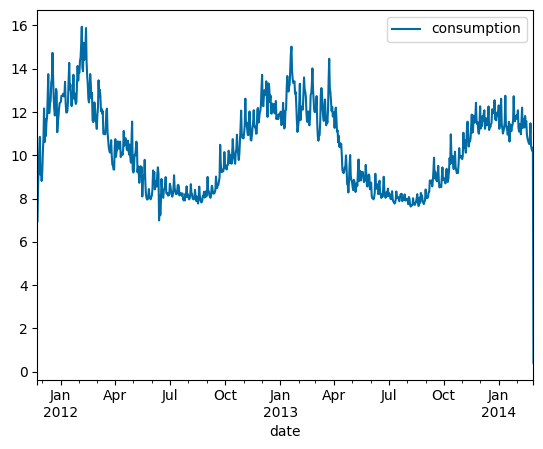

In [ ]:
df_avg_consumption.plot(x="date", y="consumption");

Estacionalidad:

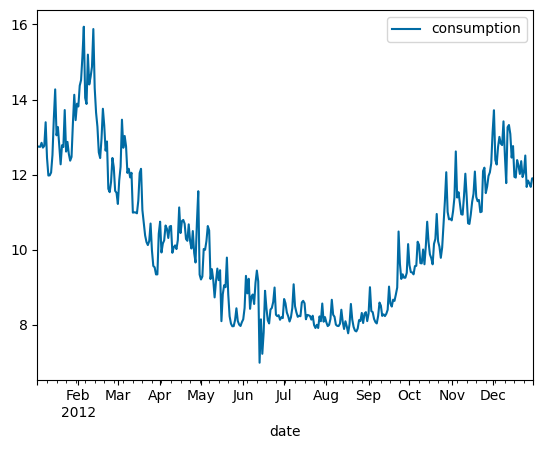

In [ ]:
df_avg_consumption.query("date > '2012-01-01' & date < '2013-01-01'").plot(x="date", y="consumption");

**Feature Enginering**

De manera similar a los ejercicios anteriores....Para entrenar un modelo como XGBoost y LightGB necesitamos crear las funciones nosotros mismos. Actualmente, solo tenemos una característica: la fecha completa. Podemos extraer diferentes características en función de la fecha completa como el día de la semana, el día del año, el mes y otros.

In [ ]:
df_avg_consumption["day_of_week"] = df_avg_consumption["date"].dt.dayofweek
df_avg_consumption["day_of_year"] = df_avg_consumption["date"].dt.dayofyear
df_avg_consumption["month"] = df_avg_consumption["date"].dt.month
df_avg_consumption["quarter"] = df_avg_consumption["date"].dt.quarter
df_avg_consumption["year"] = df_avg_consumption["date"].dt.year

df_avg_consumption.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year
0,2011-11-23,6.952692,2,327,11,4,2011
1,2011-11-24,8.536480,3,328,11,4,2011
2,2011-11-25,9.499781,4,329,11,4,2011
3,2011-11-26,10.267707,5,330,11,4,2011
4,2011-11-27,10.850805,6,331,11,4,2011


**Separación de los datos para el modelado:**

Hasta aqui... date no fue tratada como index. Podemos utilizarla para separar los datos y luego eliminarla.

Para el conjunto de pruebas usaremos solo los últimos 6 meses. Si el conjunto de entrenamiento fuera más grande, habríamos utilizado todo el último año como conjunto de pruebas.

In [ ]:
training_mask = df_avg_consumption["date"] < "2013-07-28"
training_data = df_avg_consumption.loc[training_mask]
print(training_data.shape)

testing_mask = df_avg_consumption["date"] >= "2013-07-28"
testing_data = df_avg_consumption.loc[testing_mask]
print(testing_data.shape)

(613, 7)
(216, 7)


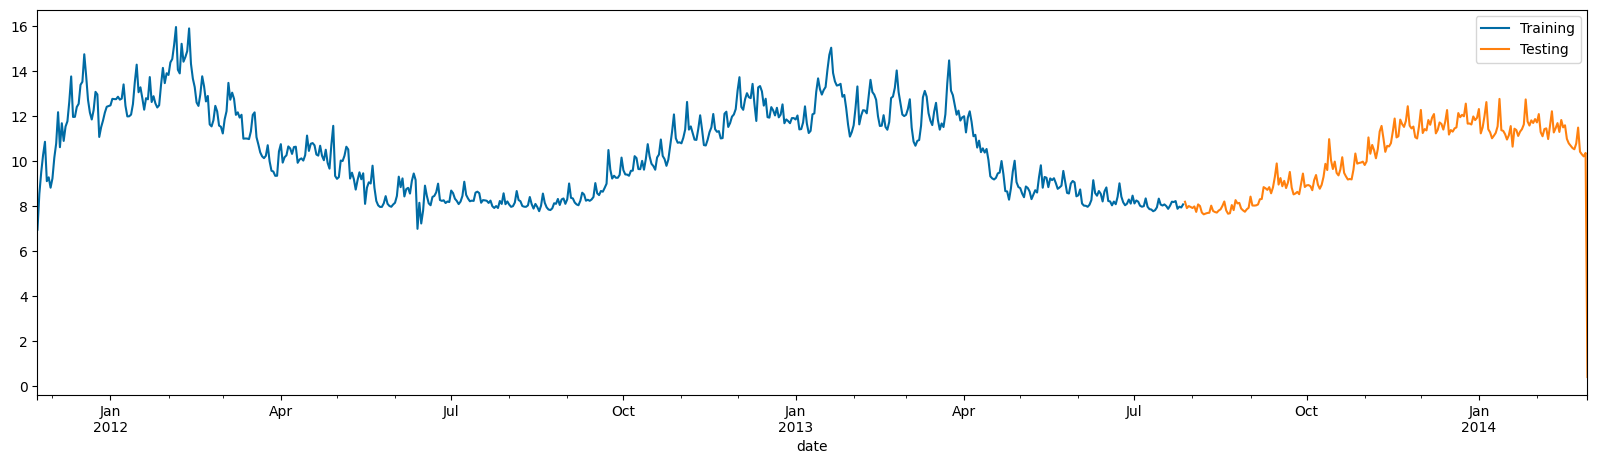

In [ ]:
figure, ax = plt.subplots(figsize=(20, 5))
training_data.plot(ax=ax, label="Training", x="date", y="consumption")
testing_data.plot(ax=ax, label="Testing", x="date", y="consumption")
plt.show()

In [ ]:
# Dropping unnecessary `date` column
training_data = training_data.drop(columns=["date"])
testing_dates = testing_data["date"]
testing_data = testing_data.drop(columns=["date"])

X_train = training_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_train = training_data["consumption"]

X_test = testing_data[["day_of_week", "day_of_year", "month", "quarter", "year"]]
y_test = testing_data["consumption"]

**Entrenamiento del modelo:**

La optimización de los hiperparámetros se realizará con gridsearch, la cual toma parámetros y algunos valores como configuración y prueba todas las combinaciones posibles.

Nuevamente, debido a la naturaleza del problema, no podemos simplemente usar una validación cruzada simple de k veces. Scikit learn proporciona el método TimeSeriesSplit que divide los datos de forma incremental de manera respetuosa en términos de continuidad.

**Para Catboost:**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# CatBoost
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = CatBoostRegressor()
model = CatBoostRegressor(learning_rate=0.1, n_estimators=100, depth=7)

parameters = {
    "depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "n_estimators": [100, 300, 500, 700, 900, 1000],
    "colsample_bylevel": [0.3, 0.5, 0.7]
}

grid_search = GridSearchCV(estimator=model, cv=cv_split, param_grid=parameters)
grid_search.fit(X_train, y_train)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
0:	learn: 1.5579796	total: 527us	remaining: 474ms
1:	learn: 1.3160823	total: 1.24ms	remaining: 555ms
2:	learn: 1.1055539	total: 2.43ms	remaining: 726ms
3:	learn: 0.9691514	total: 3.16ms	remaining: 707ms
4:	learn: 0.8690752	total: 4.2ms	remaining: 752ms
5:	learn: 0.8019357	total: 5.36ms	remaining: 799ms
6:	learn: 0.7509705	total: 5.99ms	remaining: 764ms
7:	learn: 0.7147427	total: 7.08ms	remaining: 790ms
8:	learn: 0.6867416	total: 7.81ms	remaining: 773ms
9:	learn: 0.6636676	total: 8.66ms	remaining: 771ms
10:	learn: 0.6239163	total: 9.71ms	remaining: 785ms
11:	learn: 0.6165503	total: 10.2ms	remaining: 758ms
12:	learn: 0.6036372	total: 11.2ms	remaining: 763ms
13:	learn: 0.5901535	total: 12.1ms	remaining: 767ms
14:	learn: 0.5782977	total: 13.2ms	remaining: 781ms
15:	learn: 0.5719929	total: 14ms	remaining: 772ms
16:	learn: 0.5620224	total: 15.1ms	remaining: 785ms
17:	learn: 0.5593991	total: 15.7ms	remaining: 771ms
18:	learn: 

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=100),
             estimator=<catboost.core.CatBoostRegressor object at 0x7ef947a2dc60>,
             param_grid={'colsample_bylevel': [0.3, 0.5, 0.7],
                         'depth': [3, 4, 5, 6, 7],
                         'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
                         'n_estimators': [100, 300, 500, 700, 900, 1000]})

**Evaluación**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,\
  mean_squared_error

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"MAPE: {mean_absolute_percentage_error(y_test, prediction)}")

def plot_predictions(testing_dates, y_test, prediction):
  df_test = pd.DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  figure, ax = plt.subplots(figsize=(10, 5))
  df_test.plot(ax=ax, label="Actual", x="date", y="actual")
  df_test.plot(ax=ax, label="Prediction", x="date", y="prediction")
  plt.legend(["Actual", "Prediction_CatBoost"])
  plt.show()

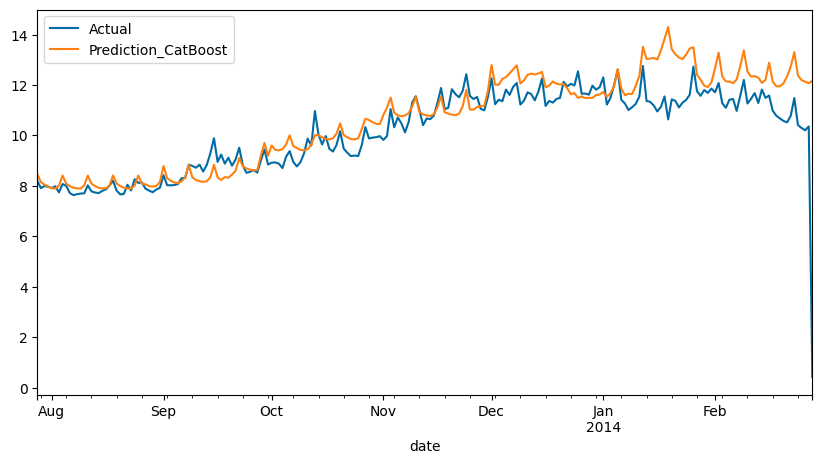

MAE: 0.6612588948102058
MSE: 1.3208680781064428
MAPE: 0.18774602639869814


In [ ]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)

**Random Forest**

Random Forest es un modelo de ensamble basado en árboles de decisión, y su funcionamiento no depende de un proceso iterativo de optimización como en los modelos de Gradient Boosting o redes neuronales

In [ ]:
# RandomForest
from sklearn.ensemble import RandomForestRegressor
cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
model = RandomForestRegressor()
parameters = {
    "max_depth": [3, 4, 6, 5, 10],
    "n_estimators": [50, 100, 300, 500, 700, 900, 1000],
    "min_samples_split":[2, 4, 6, 10],
    "max_leaf_nodes": [2, 4, 8]
}


grid_search = GridSearchCV(estimator=model, cv=cv_split, param_grid=parameters)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=100),
             estimator=RandomForestRegressor(),
             param_grid={'max_depth': [3, 4, 6, 5, 10],
                         'max_leaf_nodes': [2, 4, 8],
                         'min_samples_split': [2, 4, 6, 10],
                         'n_estimators': [50, 100, 300, 500, 700, 900, 1000]})

In [ ]:
def plot_predictions(testing_dates, y_test, prediction):
  df_test = pd.DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  figure, ax = plt.subplots(figsize=(10, 5))
  df_test.plot(ax=ax, label="Actual", x="date", y="actual")
  df_test.plot(ax=ax, label="Prediction", x="date", y="prediction")
  plt.legend(["Actual", "Prediction_RandomForest"])
  plt.show()

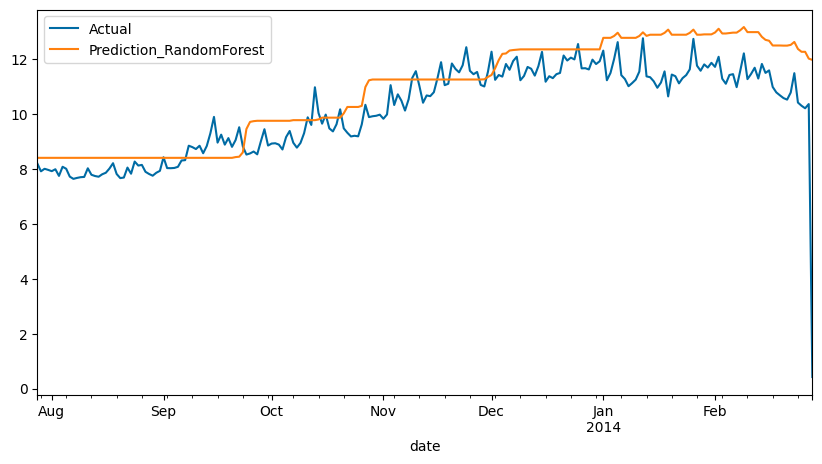

MAE: 0.8681576680130768
MSE: 1.555146289753081
MAPE: 0.20743022622143034


In [ ]:
# Evaluating GridSearch results
prediction = grid_search.predict(X_test)
plot_predictions(testing_dates, y_test, prediction)
evaluate_model(y_test, prediction)